# DATASET GENERATION

In [1]:
# CODE TO GENERATE A SYNTHETIC RAMAN DATASET FOR NEURAL NETWORK TRAINING

import numpy as np
import h5py
import json
import itertools
from RamanModel import generateCurve, addNoiseSNR
from HelperFunctions import downsample_and_normalize

def generate_raman_dataset(n, peak_counts, noise_sigmas, parameters, resolution, filename="raman_training.h5"):
    """
    Generates a balanced dataset of Raman curves and saves them to an HDF5 file.
    
    Args:
        n (int): Total number of curves to generate.
        peak_counts (list): List of possible number of peaks (e.g., [1, 2, 3]).
        noise_sigmas (list): List of noise standard deviations (e.g., [0.01, 0.05]).
        parameters (dict): The range parameters for centers, amplitudes, and gammas.
        resolution (int): The number of points in each curve.
        filename (str): The name of the output HDF5 file.
    """
    # 1. Calculate combinations and distribution for balance
    combinations = list(itertools.product(peak_counts, noise_sigmas))
    num_combinations = len(combinations)
    
    # Calculate samples per combination
    samples_per_combo = n // num_combinations
    remainder = n % num_combinations
    
    # Distribute the total n samples (handling the remainder if n is not divisible)
    samples_distribution = [samples_per_combo + (1 if i < remainder else 0) for i in range(num_combinations)]
    
    # 2. Data Containers
    all_y = []
    all_peak_params = []
    all_num_peaks = []
    all_noise = []
    x_values_shared = None

    print(f"Generating balanced dataset of {n} curves...")
    current_idx = 0
    # 3. Generate Curves
    for (num_peaks, sigma), count in zip(combinations, samples_distribution):
        for _ in range(count):
            print(f"Generating curve {current_idx} of {n} (Peaks: {num_peaks}, Sigma: {sigma})...", end="\r", flush=True)
            current_idx += 1

            x, y, params = generateCurve(parameters, num_peaks, resolution, 0)
            y, _ = addNoiseSNR(y, sigma)
            y = downsample_and_normalize(y, resolution) # Normalization only
            #y = y/max(y)
            
            # Save x values only once
            if x_values_shared is None:
                x_values_shared = x
            
            all_y.append(y)
            all_num_peaks.append(num_peaks)
            # Parameters are saved as JSON strings to maintain structure in HDF5
            all_peak_params.append(json.dumps(params))
            all_noise.append(sigma)

    # Convert to numpy arrays
    all_y = np.array(all_y)
    all_num_peaks = np.array(all_num_peaks)
    all_noise = np.array(all_noise)

    # 4. Save to HDF5
    with h5py.File(filename, 'w') as hf:
        # Save shared x values
        hf.create_dataset("x_values", data=x_values_shared)
        
        # Save intensities (y values)
        hf.create_dataset("y_values", data=all_y)
        
        # Save number of peaks per curve
        hf.create_dataset("num_peaks", data=all_num_peaks)

        # Save the noise values
        hf.create_dataset("noise", data=all_noise)
        
        # Save peak parameters as variable-length strings (JSON formatted)
        dt = h5py.special_dtype(vlen=str)
        ds_params = hf.create_dataset("peak_parameters", (n,), dtype=dt)
        ds_params[:] = all_peak_params

    print(f"Successfully saved dataset to '{filename}'.")

In [5]:
peak_counts_list = [1, 2, 3, 4, 5]
noise_list = np.linspace(1, 10, num=10)
raman_params = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.003, 0.05),
    "x_min": 0,
    "x_max": 1
 }

In [3]:
# EXECUTION BLOCK TO GENERATE TRAINING AND TEST DATASETS



generate_raman_dataset(n=10000, 
                        peak_counts=peak_counts_list, 
                        noise_sigmas=noise_list, 
                        parameters=raman_params, 
                        resolution=1000,
                        filename="algs_data/data_test_algs.h5"
                        )

Generating balanced dataset of 10000 curves...
Successfully saved dataset to 'algs_data/data_test_algs.h5'.


# ALGO DEFINITION

In [1]:
from RamanModel import *
from HelperFunctions import *
from Plots import *
from lmfit import Model, Parameters

In [2]:
@njit(fastmath=True)
def add_lorentzian(curve, x, x0, gamma, maximum):
    gamma_sq = gamma * gamma

    for i in range(len(x)):
        dx = x[i] - x0
        curve[i] += (maximum * gamma_sq) / (gamma_sq + dx * dx)

@njit(fastmath=True)
def normalize_curve(curve):
    top = np.max(curve)
    if top > 0:
        curve /= top

@njit(fastmath=True)
def preallocate_centers(array, samples, num_peaks, probs, x_range):
    for sample_idx in range(samples):
        for peak_idx in range(num_peaks):
            array[sample_idx, peak_idx] = position_probability_map(probs, x_range)

def knnFit_persistent(samples, base_parameters, target_x, target_y, num_peaks=4, k=10, rounds=3, eps=0.15):
    peak_search_spaces = []
    
    for _ in range(num_peaks):
        peak_search_spaces.append({
            "center_range": list(base_parameters["center_range"]),
            "amplitude_range": list(base_parameters["amplitude_range"]),
            "gamma_range": list(base_parameters["gamma_range"])
        })

    # MOVE HEAP OUTSIDE THE ROUNDS LOOP
    heap = []
    best_neighbor_params = []

    # DEFINE X RANGE FOR PROB MAP SAMPLING
    x_range = np.linspace(0, 1, len(target_y))

    # CALCULATE PROBABILITY MAP FOR FIRST PASS
    probs = create_probability_map(target_y, num_peaks=num_peaks, resolution=50)
    first_round_centers = np.empty((samples, num_peaks))
    preallocate_centers(first_round_centers, samples, num_peaks, probs, x_range)
    

    #######################################################
    ##################### Nth PASS ########################
    #######################################################
    
    for r in range(rounds):
        current_y = np.empty_like(target_x)
        
        # INITIALIZE PARAMETERS

        centers = np.empty((samples, num_peaks))
        amps    = np.empty((samples, num_peaks))
        gammas  = np.empty((samples, num_peaks))

        for i in range(num_peaks):
            p = peak_search_spaces[i]
        
            centers[:, i] = np.random.uniform(
                p["center_range"][0],
                p["center_range"][1],
                size=samples
            )
        
            amps[:, i] = np.random.uniform(
                p["amplitude_range"][0],
                p["amplitude_range"][1],
                size=samples
            )
        
            gammas[:, i] = np.random.uniform(
                p["gamma_range"][0],
                p["gamma_range"][1],
                size=samples
            )

        # START LOOP
        for sample_idx in range(samples):
            #current_y = np.zeros(len(target_x))
            current_y.fill(0.0)
            current_params = []

            for i in range(num_peaks):
                p = peak_search_spaces[i]

                if (r == 0):
                    #c = position_probability_map(probs, x_range)
                    c = first_round_centers[sample_idx, i]
                else:
                    c = centers[sample_idx, i]
                a = amps[sample_idx, i]
                g = gammas[sample_idx, i]

                add_lorentzian(current_y, target_x, c, g, a)
                current_params.append({"center": c, "amplitude": a, "gamma": g})

            normalize_curve(current_y)

            dist = euclidean_distance(target_y, current_y)

            if len(heap) < k:
                heapq.heappush(heap, (-dist, sample_idx, current_params))
            else:
                if -dist > heap[0][0]:
                    heapq.heapreplace(heap, (-dist, sample_idx, current_params))
                    
        # --- DBSCAN-Style Clustering with Origin Tracking ---
        nearest_neighbors = [item[2] for item in heap]

        all_candidate_peaks = []
        for neighbor_id, neighbor_params in enumerate(nearest_neighbors):
            for peak in neighbor_params:
                # Store the peak data AND which curve it belongs to
                all_candidate_peaks.append({
                    "data": peak,
                    "origin_curve": neighbor_id
                })

        visited = [False] * len(all_candidate_peaks)
        valid_clusters = []

        for i in range(len(all_candidate_peaks)):
            if visited[i]: continue

            cluster_indices = [i]
            # Tracking which curves have contributed to this cluster
            curves_in_cluster = {all_candidate_peaks[i]["origin_curve"]}

            for j in range(len(all_candidate_peaks)):
                if i == j: continue

                dist = get_param_distance(
                    all_candidate_peaks[i]["data"],
                    all_candidate_peaks[j]["data"],
                    base_parameters
                )

                if dist < eps:
                    cluster_indices.append(j)
                    curves_in_cluster.add(all_candidate_peaks[j]["origin_curve"])

            # CRITICAL CHECK: Does a majority of DIFFERENT curves agree?
            if len(curves_in_cluster) > (k // 2):
                valid_clusters.append(cluster_indices)
                # Mark peaks in this cluster as visited
                for idx in cluster_indices:
                    visited[idx] = True

        # Sort and update search spaces
        valid_clusters.sort(key=lambda c_idx: np.mean([all_candidate_peaks[idx]['data']['center'] for idx in c_idx]))

        for p_idx, cluster_indices in enumerate(valid_clusters[:num_peaks]):
            c_vals = [all_candidate_peaks[i]['data']['center'] for i in cluster_indices]
            a_vals = [all_candidate_peaks[i]['data']['amplitude'] for i in cluster_indices]
            g_vals = [all_candidate_peaks[i]['data']['gamma'] for i in cluster_indices]

            peak_search_spaces[p_idx]["center_range"] = [min(c_vals), max(c_vals)]
            peak_search_spaces[p_idx]["amplitude_range"] = [min(a_vals), max(a_vals)]
            peak_search_spaces[p_idx]["gamma_range"] = [min(g_vals), max(g_vals)]


        best_neighbor_params = max(heap, key=lambda x: x[0])[2]

    return best_neighbor_params, nearest_neighbors

In [3]:
# THIS SEGMENT IS AI CODE SO I MUST REVIEW THIS

def composite_lorentzian_model(x, **params):
    """Sums multiple Lorentzians based on prefixes (p0_, p1_, etc.)"""
    y = np.zeros_like(x)
    prefixes = sorted(set(p.split('_')[0] for p in params.keys()))
    for pref in prefixes:
        y += lorentzian(x, params[f'{pref}_x0'], params[f'{pref}_gamma'], params[f'{pref}_maximum'])
    return y

def refine_knn_with_lmfit(neighbors, target_x, target_y):
    """
    Refines KNN neighbors using lmfit and returns the single best result 
    based on the lowest chi-square residual.
    """
    model = Model(composite_lorentzian_model)
    all_results = []
    
    # 1. Align neighbors by center to ensure consistency
    sorted_neighbors = [sorted(n, key=lambda p: p['center']) for n in neighbors]
    num_peaks = len(sorted_neighbors[0])
    
    # --- Step A: Refine every individual neighbor ---
    for peaks in sorted_neighbors:
        pars = Parameters()
        for i, p in enumerate(peaks):
            pref = f"p{i}_"
            pars.add(f"{pref}x0", value=p['center'], min=target_x.min(), max=target_x.max())
            pars.add(f"{pref}gamma", value=p['gamma'], min=1e-5)
            pars.add(f"{pref}maximum", value=p['amplitude'], min=0)
            
        res = model.fit(target_y, pars, x=target_x)
        all_results.append(res)

    # --- Step B: Refine the mean parameters ---
    mean_pars = Parameters()
    for i in range(num_peaks):
        pref = f"p{i}_"
        avg_x0 = np.mean([n[i]['center'] for n in sorted_neighbors])
        avg_gamma = np.mean([n[i]['gamma'] for n in sorted_neighbors])
        avg_max = np.mean([n[i]['amplitude'] for n in sorted_neighbors])
        
        mean_pars.add(f"{pref}x0", value=avg_x0, min=target_x.min(), max=target_x.max())
        mean_pars.add(f"{pref}gamma", value=avg_gamma, min=1e-5)
        mean_pars.add(f"{pref}maximum", value=avg_max, min=0)

    mean_res = model.fit(target_y, mean_pars, x=target_x)
    all_results.append(mean_res)

    # --- Step C: Select the best fit (smallest chi-square) ---
    # chisqr is the sum of squared residuals
    best_result = min(all_results, key=lambda r: r.chisqr)
    
    #print(f"Best fit found with Chi-Square: {best_result.chisqr:.6f}")
    return best_result

# Example Usage:
# best_fit_model = refine_knn_with_lmfit(neighbors_params, target_x, target_y)
#
# # To see the optimized parameters:
# print(best_fit_model.fit_report())
#
# # To plot the result:
# plt.plot(target_x, target_y, label="Data")
# plt.plot(target_x, best_fit_model.best_fit, label="Best Refined Fit")

# FITTING THE DATA

In [6]:
import json
import h5py
import numpy as np
import time

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def extract_fit_parameters(result):
    """
    Extract fitted Lorentzian parameters from an lmfit result.
    Returns:
        [
            {
                "center": ...,
                "amplitude": ...,
                "gamma": ...
            },
            ...
        ]
    """

    peaks = []

    prefixes = sorted(
        set(name.split("_")[0]
            for name in result.params.keys())
    )

    for pref in prefixes:

        peaks.append({
            "center": float(result.params[f"{pref}_x0"].value),
            "amplitude": float(result.params[f"{pref}_maximum"].value),
            "gamma": float(result.params[f"{pref}_gamma"].value)
        })

    return peaks


def compute_curve_chi2(y_true, y_fit):
    """
    Explicit chi-square-like metric.
    Since spectra are normalized and no uncertainties exist,
    this is effectively the residual sum of squares.
    """

    return np.sum((y_true - y_fit) ** 2)


# ============================================================
# LOAD DATASET
# ============================================================

with h5py.File("algs_data/data_test_algs.h5", "r") as hf:

    x_values = hf["x_values"][:]

    y_values = hf["y_values"][:]

    num_peaks_arr = hf["num_peaks"][:]

    noise_arr = hf["noise"][:]

    true_peak_json = hf["peak_parameters"][:]

N = len(y_values)

print(f"Loaded {N} spectra")

# ============================================================
# STORAGE
# ============================================================

curve_indices = []

fitted_parameter_json = []

chi2_values = []

fitted_curves = []

# Keep originals too for convenience
saved_num_peaks = []
saved_noise = []
saved_true_params = []

# ============================================================
# FITTING LOOP
# ============================================================

for i in range(N):

    print(f"Processing spectrum {i+1}/{N}", end="\r", flush=True)

    target_y = y_values[i]

    num_peaks = int(num_peaks_arr[i])

    # --------------------------------------------------------
    # KNN search
    # --------------------------------------------------------

    best_neighbor, neighbors = knnFit_persistent(
        samples=10000,
        base_parameters=raman_params,
        target_x=x_values,
        target_y=target_y,
        num_peaks=num_peaks,
        k=10,
        rounds=3,
        eps=0.15
    )

    # --------------------------------------------------------
    # LMFit refinement
    # --------------------------------------------------------

    result = refine_knn_with_lmfit(
        neighbors,
        x_values,
        target_y
    )

    # --------------------------------------------------------
    # Extract outputs
    # --------------------------------------------------------

    fitted_peaks = extract_fit_parameters(result)

    fitted_y = result.best_fit

    chi2 = compute_curve_chi2(
        target_y,
        fitted_y
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    curve_indices.append(i)

    fitted_parameter_json.append(
        json.dumps(fitted_peaks)
    )

    chi2_values.append(chi2)

    fitted_curves.append(fitted_y)

    saved_num_peaks.append(num_peaks_arr[i])

    saved_noise.append(noise_arr[i])

    saved_true_params.append(
        true_peak_json[i]
    )

    #print(
    #    f"   Peaks={num_peaks} | "
    #    f"Noise={noise_arr[i]} | "
    #    f"Chi²={chi2:.6f}"
    #)

# ============================================================
# CONVERT TO NUMPY
# ============================================================

curve_indices = np.array(curve_indices)

chi2_values = np.array(chi2_values)

fitted_curves = np.array(fitted_curves)

saved_num_peaks = np.array(saved_num_peaks)

saved_noise = np.array(saved_noise)

# ============================================================
# SAVE FITTED DATASET
# ============================================================

with h5py.File("algs_data/data_test_algs_fitted_1.h5", "w") as hf:

    # Useful for reconstruction
    hf.create_dataset(
        "x_values",
        data=x_values
    )

    # Index back into original dataset
    hf.create_dataset(
        "curve_index",
        data=curve_indices
    )

    # Metadata
    hf.create_dataset(
        "num_peaks",
        data=saved_num_peaks
    )

    hf.create_dataset(
        "noise",
        data=saved_noise
    )

    # Original spectra
    hf.create_dataset(
        "original_y",
        data=y_values
    )

    # Fitted spectra
    hf.create_dataset(
        "fitted_y",
        data=fitted_curves
    )

    # Explicit chi-square metric
    hf.create_dataset(
        "chi2",
        data=chi2_values
    )

    # --------------------------------------------------------
    # Variable-length JSON strings
    # --------------------------------------------------------

    dt = h5py.special_dtype(vlen=str)

    ds_true = hf.create_dataset(
        "true_parameters",
        (N,),
        dtype=dt
    )

    ds_true[:] = saved_true_params

    ds_fit = hf.create_dataset(
        "fitted_parameters",
        (N,),
        dtype=dt
    )

    ds_fit[:] = fitted_parameter_json


print("Saved fitted dataset -> raman_fitted.h5")

Loaded 10000 spectra
Saved fitted dataset -> raman_fitted.h5


# GRAPHING

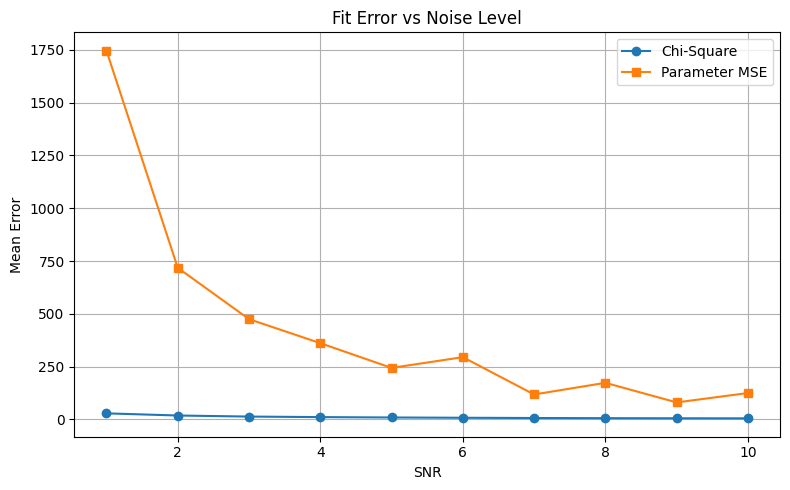

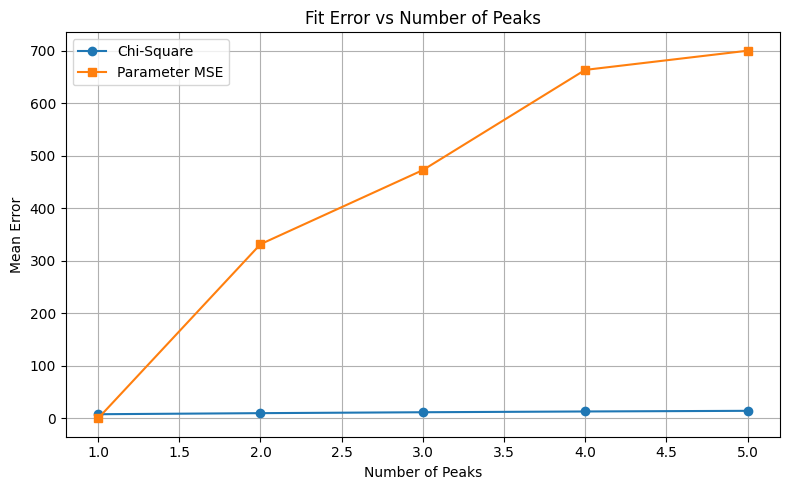

In [10]:
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD FITTED DATASET
# ============================================================

with h5py.File("algs_data/data_test_algs_fitted.h5", "r") as hf:

    noise = hf["noise"][:]

    num_peaks = hf["num_peaks"][:]

    chi2 = hf["chi2"][:]

    true_parameters = hf["true_parameters"][:]

    fitted_parameters = hf["fitted_parameters"][:]

# ============================================================
# PARAMETER MSE
# ============================================================

parameter_mse = []

for true_json, fit_json in zip(
    true_parameters,
    fitted_parameters
):

    true_peaks = json.loads(true_json)
    fit_peaks = json.loads(fit_json)

    # Sort by center so corresponding peaks align
    true_peaks = sorted(
        true_peaks,
        key=lambda p: p["center"]
    )

    fit_peaks = sorted(
        fit_peaks,
        key=lambda p: p["center"]
    )

    squared_errors = []

    for t, f in zip(true_peaks, fit_peaks):

        squared_errors.append(
            (t["center"] - f["center"])**2
        )

        squared_errors.append(
            (t["amplitude"] - f["amplitude"])**2
        )

        squared_errors.append(
            (t["gamma"] - f["gamma"])**2
        )

    parameter_mse.append(
        np.mean(squared_errors)
    )

parameter_mse = np.array(parameter_mse)

# ============================================================
# GROUP BY NOISE
# ============================================================

unique_noise = np.sort(
    np.unique(noise)
)

noise_mean_chi2 = []

noise_mean_mse = []

for n in unique_noise:

    mask = noise == n

    noise_mean_chi2.append(
        np.mean(chi2[mask])
    )

    noise_mean_mse.append(
        np.mean(parameter_mse[mask])
    )

# ============================================================
# GROUP BY NUMBER OF PEAKS
# ============================================================

unique_peaks = np.sort(
    np.unique(num_peaks)
)

peak_mean_chi2 = []

peak_mean_mse = []

for p in unique_peaks:

    mask = num_peaks == p

    peak_mean_chi2.append(
        np.mean(chi2[mask])
    )

    peak_mean_mse.append(
        np.mean(parameter_mse[mask])
    )

# ============================================================
# PLOT 1
# Error vs Noise
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    unique_noise,
    noise_mean_chi2,
    marker='o',
    label='Chi-Square'
)

plt.plot(
    unique_noise,
    noise_mean_mse,
    marker='s',
    label='Parameter MSE'
)

plt.xlabel("SNR")
plt.ylabel("Mean Error")
plt.title("Fit Error vs Noise Level")

plt.grid(True)
plt.legend()

plt.tight_layout()

# ============================================================
# PLOT 2
# Error vs Number of Peaks
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    unique_peaks,
    peak_mean_chi2,
    marker='o',
    label='Chi-Square'
)

plt.plot(
    unique_peaks,
    peak_mean_mse,
    marker='s',
    label='Parameter MSE'
)

plt.xlabel("Number of Peaks")
plt.ylabel("Mean Error")
plt.title("Fit Error vs Number of Peaks")

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.show()